# Part 3 - Advanced Machine Learning
In part one we achieved around 67% accuracy on GalaxyMNIST using a kNN-classifier. Ultimately our goal is to get the highest possible score on GalaxyMNIST which can most likely be achieved using Convolutional Neural Networks. It is good practice to compare against simple baselines when developing more complex models. In this notebook, we will start with simple non-neural network classifiers and then move on to fully connected and convolutional neural networks.

In [1]:
%load_ext autoreload
%autoreload 2
from IPython.display import display

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch, gzip, requests

from torchvision import transforms
from torch.utils.data import DataLoader

import time

from Part03.device_management import get_device

# dataset
from galaxy_mnist import GalaxyMNIST

download_data = [
    {"url":"https://www.dropbox.com/scl/fi/l4ap5eq7z49l27dnfw076/train_dataset.hdf5.gz?rlkey=gjfrrrouoah0hbydbkpfx66as&st=tw6znd55&dl=1", "file":"train_dataset.hdf5"},
    {"url":"https://www.dropbox.com/scl/fi/ty43vhrrpa8cf8azn3awn/test_dataset.hdf5.gz?rlkey=jmlkzjiguhe271nbuzpa0njna&st=5oco8ika&dl=1", "file":"test_dataset.hdf5"}
]

root = Path("raw_galaxy_mnist")
raw = root/"GalaxyMNIST"/"raw"
raw.mkdir(parents=True, exist_ok=True)
for d in download_data:
    p = raw/d["file"]
    if not p.exists():
        r = requests.get(d["url"], timeout=60)
        p.write_bytes(gzip.decompress(r.content))


transform = transforms.ToTensor()

train_dataset = GalaxyMNIST(root=root, train=True, transform=transform)
test_dataset = GalaxyMNIST(root=root, train=False, transform=transform)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True, num_workers=4)

DEVICE = get_device()
print(f'Using: {DEVICE}')

Using: cpu


In [2]:
train_flat = train_dataset.data.flatten(1).numpy()
test_flat = test_dataset.data.flatten(1).numpy()

train_labels = train_dataset.targets.numpy()
test_labels = test_dataset.targets.numpy()

## 3.1 Classical Algorithms
- Identify at least three classification algorithms that can be used for image classification.
- Explain briefly how they work and use them to classify the dataset. Use scikit-learn or other library implementations rather than implementing these yourself.
- Compare their metrics and runtime, which is best?

For possible algorithm options you can get inspired [here](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html).

---

We chose the following three classification algorithms; RBF SVM, the Gaussian Process and the Naive Bayesian approach.
These are visually represented below, where we generate three random 2d datasets and show what each model would classify each point as.
This application doubles as a test of the performance of the various methods.
The "training" and test runtimes as well as the test score are saved and compiled into the data frame shown below.
"Training" time is the runtime to initialize the model, and test runtime is how long it takes to evaluate the model on the test dataset.
Finally, test score is the accuracy (ratio of correct to total predictions) of the model on the test data.

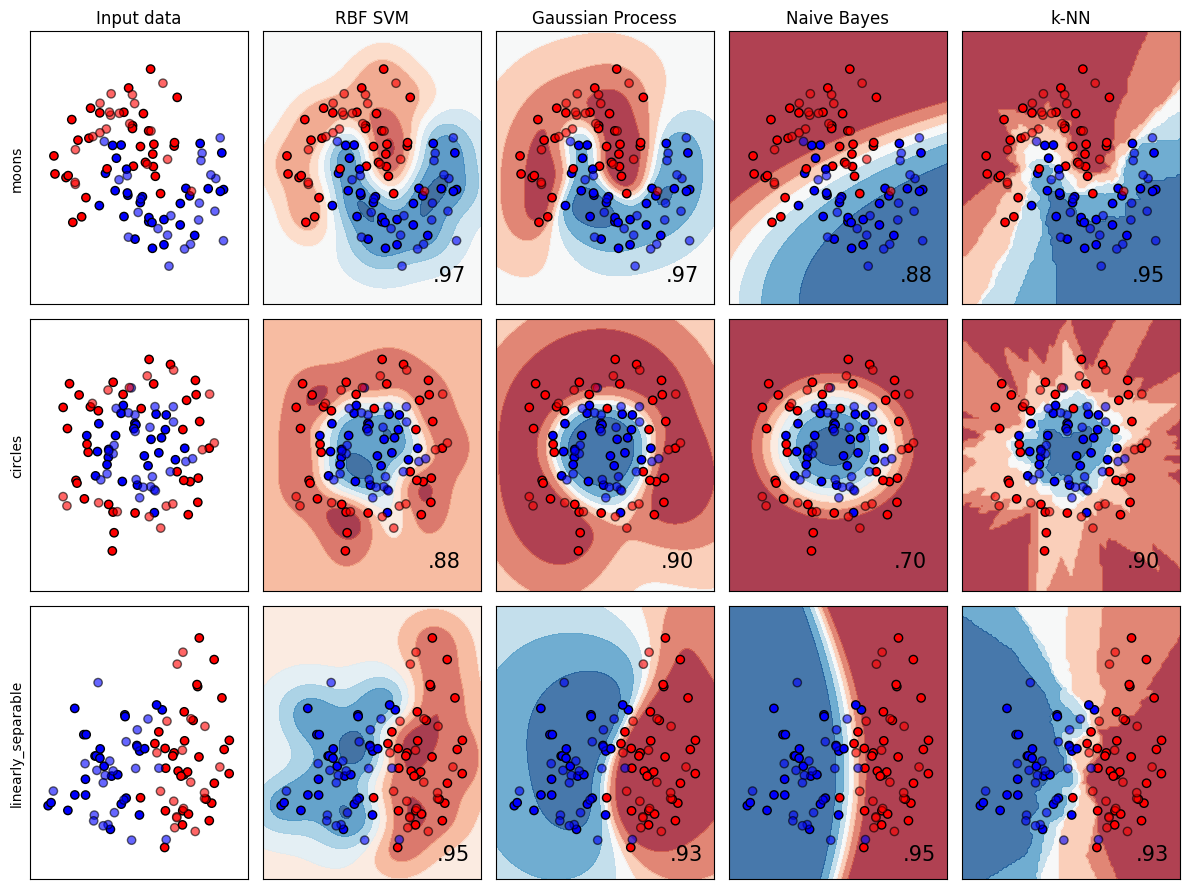

In [3]:
from sklearn.datasets import make_circles, make_classification, make_moons

from sklearn.svm import SVC

from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process import GaussianProcessClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.neighbors import KNeighborsClassifier

from Part03.classical_algorithms import example_of_algorithms, style_dataframe

classifiers_names = [
    "RBF SVM",
    "Gaussian Process",
    "Naive Bayes",
    "k-NN"
]
classifiers = [
    SVC(gamma=2, C=1, random_state=1),
    GaussianProcessClassifier(1.0 * RBF(1.0), random_state=1),
    GaussianNB(),
    KNeighborsClassifier(n_neighbors=9),
]

X, y = make_classification(
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=1,
    n_clusters_per_class=1,
)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

datasets = [
    make_moons(noise=0.3, random_state=0),
    make_circles(noise=0.2, factor=0.5, random_state=1),
    linearly_separable,
]
datasets_names = [
    'moons',
    'circles',
    'linearly_separable',
]

# side effect -> plots everything
results = example_of_algorithms(
    classifiers,
    classifiers_names,
    datasets,
    datasets_names,
)

In [4]:
# create a dataframe of the results
df = pd.DataFrame(results)

df["classifier"] = pd.Categorical(
    df["classifier"],
    categories=classifiers_names,
    ordered=True
)
df["dataset"] = pd.Categorical(
    df["dataset"],
    categories=datasets_names,
    ordered=True
)

df.sort_values("classifier", inplace=True)

In [5]:
styled = style_dataframe(
    df,
    ['score', 'train_runtime', 'test_runtime'],
    ['high', 'low', 'low']
)
styled.hide(axis='index')

display(styled)

classifier,dataset,score,train_runtime,test_runtime
RBF SVM,moons,0.975000,0.000905,0.000368
RBF SVM,circles,0.875000,0.000748,0.000344
RBF SVM,linearly_separable,0.950000,0.000665,0.000307
Gaussian Process,moons,0.975000,0.018641,0.000333
Gaussian Process,circles,0.900000,0.023894,0.000299
Gaussian Process,linearly_separable,0.925000,0.163827,0.000305
Naive Bayes,moons,0.875000,0.000723,0.000293
Naive Bayes,circles,0.700000,0.000646,0.000280
Naive Bayes,linearly_separable,0.950000,0.000599,0.000268
k-NN,moons,0.950000,0.000723,0.000976


In [6]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

DATASET_NAME = 'GalaxyMNIST'

results = []
trials = 1
train_size = 1000
test_size = 500
np.random.seed(0)

for name, clf in zip(classifiers_names, classifiers):
    print(f'Starting: {name}')
    for i in range(trials):
        train_start_idx = np.random.randint(0, len(train_flat) - train_size)
        test_start_idx = np.random.randint(0, len(test_flat) - test_size)

        clf_pipeline = make_pipeline(StandardScaler(), clf)

        tr_st = time.perf_counter()
        clf_pipeline.fit(
            train_flat[train_start_idx:train_start_idx + train_size],
            train_labels[train_start_idx:train_start_idx + train_size]
        )
        tr_et = time.perf_counter()
        te_st = time.perf_counter()
        score = clf_pipeline.score(
            test_flat[test_start_idx:test_start_idx + test_size],
            test_labels[test_start_idx:test_start_idx + test_size]
        )
        te_et = time.perf_counter()

        tr_rt = tr_et - tr_st
        te_rt = te_et - te_st
        results.append({
            'classifier': name,
            'dataset': DATASET_NAME, 
            'score': score,
            'train_runtime': tr_rt,
            'test_runtime': te_rt
        })
        print(f'\t{i+1}/{trials} trials', end='\r')
    print(f'\t{trials}/{trials} trials, Done!')
    print(f'Finished: {name}')
print('Done!')

Starting: RBF SVM
	1/1 trials, Done!
Finished: RBF SVM
Starting: Gaussian Process
	1/1 trials, Done!
Finished: Gaussian Process
Starting: Naive Bayes
	1/1 trials, Done!
Finished: Naive Bayes
Starting: k-NN
	1/1 trials, Done!
Finished: k-NN
Done!


In [24]:
df = pd.DataFrame(results)

styled = style_dataframe(
    df,
    ['score', 'train_runtime', 'test_runtime'],
    ['high', 'low', 'low']
)
styled.hide(axis='index')

display(styled)

classifier,dataset,score,train_runtime,test_runtime
RBF SVM,GalaxyMNIST,0.256000,12.383525,25.249862
Gaussian Process,GalaxyMNIST,0.250000,30.762716,6.310640
Naive Bayes,GalaxyMNIST,0.360000,0.145392,0.071100
k-NN,GalaxyMNIST,0.464000,0.078043,0.151078


In [28]:
df = df.drop(columns=['dataset'], errors='ignore')

g = df.groupby('classifier', as_index=False)
stats_df = g.agg(
    avg_score=('score', 'mean'),
    std_score=('score', 'std'),
    avg_train_runtime=('train_runtime', 'mean'),
    std_train_runtime=('train_runtime', 'std'),
    avg_test_runtime=('test_runtime', 'mean'),
    std_test_runtime=('test_runtime', 'std')
)

styled = style_dataframe(
    stats_df,
    [
        'avg_score',
        'avg_train_runtime',
        'avg_test_runtime',
        'std_score',
        'std_train_runtime',
        'std_test_runtime'
    ],
    [
        'high',    # high score is good
        'low',    # low runtime is good
        'low',    # low runtime is good
        'low',    # low std is good
        'low',    # low std is good
        'low'     # low std is good
    ]
)

print(f'Using datset: {DATASET_NAME}')
display(styled)

Using datset: GalaxyMNIST


,classifier,avg_score,std_score,avg_train_runtime,std_train_runtime,avg_test_runtime,std_test_runtime
0,Gaussian Process,0.250000,nan,30.762716,nan,6.310640,nan
1,Naive Bayes,0.360000,nan,0.145392,nan,0.071100,nan
2,RBF SVM,0.256000,nan,12.383525,nan,25.249862,nan
3,k-NN,0.464000,nan,0.078043,nan,0.151078,nan


## 3.2 Neural Networks
We will now start to use neural networks to classify the GalaxyMNIST dataset.
### 3.2.1 Multi-Layer Perceptron (MLP)
In this task you will write all the infrastructure to train and evaluate a neural network on a dataset. We recommend using PyTorch, but you can use any other framework as well. You can use [this](https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html) tutorial to get started and follow the steps below:
- Define a torch dataset (use a `TensorDataset`) and data loaders for the dataset.
- Design a simple fully connected network.
- Write a training loop which computes output, loss and does an optimization step.
- Write an evaluation function that computes the predictions of the trained model on the test set. 
- Plot the training/test loss and accuracy against the number of epochs.


---



In [9]:
from torch import nn
import Part03.MLP_implementation as MLP
from Part03.NN_training import training_step

MLP_model = MLP.NeuralNetwork().to(DEVICE)
print(MLP_model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=12288, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=4, bias=True)
  )
)


In [10]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(MLP_model.parameters(), lr=1e-3)

result = []

epochs = 8
for t in range(epochs):
    print_info = True if (t % 4 == 0 or t == epochs - 1) else False
    if print_info: print(f"---------- Epoch {t} ----------")
    res: dict = training_step(
        MLP_model,
        train_dataloader,
        test_dataloader,
        loss_fn,
        optimizer,
        DEVICE,
        print_info
    )
    result.append({'epoch': t} | res)    # union of dicts, no overwrites happen because no keys overlap
    if print_info: print()
print("Done!")

df = pd.DataFrame(result)

---------- Epoch 0 ----------
Completed:    64/ 8000    loss: 1.384950
Completed:  6464/ 8000    loss: 1.381357
Test Accuracy: 27.3 %    Test Avg. loss: 1.384728

---------- Epoch 4 ----------
Completed:    64/ 8000    loss: 1.381523
Completed:  6464/ 8000    loss: 1.383249
Test Accuracy: 25.3 %    Test Avg. loss: 1.381031

---------- Epoch 7 ----------
Completed:    64/ 8000    loss: 1.381214
Completed:  6464/ 8000    loss: 1.376145
Test Accuracy: 25.2 %    Test Avg. loss: 1.379038

Done!


In [11]:
styled = df.style.hide(axis='index')
display(styled)

epoch,training_avg_loss,training_accuracy,test_avg_loss,test_accuracy
0,1.385915,0.279625,1.384728,0.272500
1,1.384178,0.259500,1.383583,0.254500
2,1.382792,0.250875,1.382701,0.253000
3,1.381655,0.249750,1.381778,0.253000
4,1.380654,0.249500,1.381031,0.253000
5,1.379694,0.249375,1.380159,0.253000
6,1.378762,0.249875,1.379316,0.253000
7,1.377852,0.249750,1.379038,0.252500


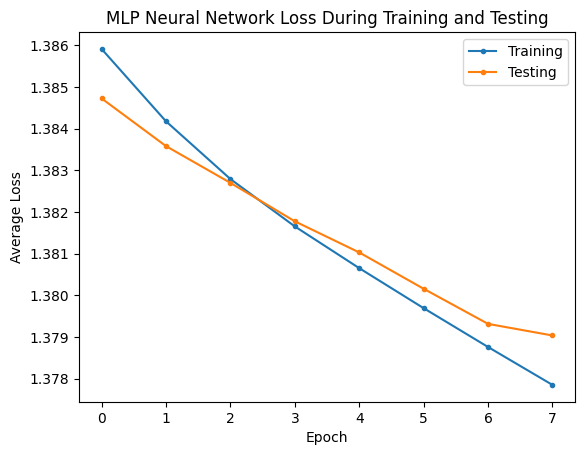

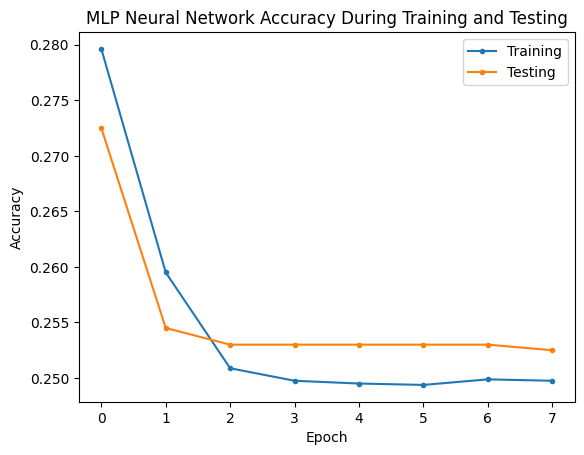

In [12]:
plt.plot(df['epoch'], df['training_avg_loss'], label='Training', marker='.')
plt.plot(df['epoch'], df['test_avg_loss'], label='Testing', marker='.')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('MLP Neural Network Loss During Training and Testing')
plt.legend()
plt.show()

plt.plot(df['epoch'], df['training_accuracy'], label='Training', marker='.')
plt.plot(df['epoch'], df['test_accuracy'], label='Testing', marker='.')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MLP Neural Network Accuracy During Training and Testing')
plt.legend()
plt.show()

### 3.2.2  CNN
MLPs are a simple form of neural networks. However, inserting prior knowledge about the structure of the data can help improve the performance. Convolutional Neural Networks (CNNs) are a type of neural network that is well-suited for image classification tasks.
- Design a CNN and train it on the dataset.
- Can an MLP learn to act like a CNN?

In [13]:
import Part03.CNN_implementation as CNN

CNN_model = CNN.Neural_Network().to(DEVICE)
print(CNN_model)

Neural_Network(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(CNN_model.parameters(), lr=1e-3)

result = []

epochs = 8
for t in range(epochs):
    print_info = True if (t % 4 == 0 or t == epochs - 1) else False
    if print_info: print(f"---------- Epoch {t} ----------")
    res: dict = training_step(
        CNN_model,
        train_dataloader,
        test_dataloader,
        loss_fn,
        optimizer,
        DEVICE,
        print_info
    )
    result.append({'epoch': t} | res)    # union of dicts, no overwrites happen because no keys overlap
    if print_info: print()
print("Done!")

df = pd.DataFrame(result)

---------- Epoch 0 ----------
Completed:    64/ 8000    loss: 1.389709
Completed:  6464/ 8000    loss: 1.383013
Test Accuracy: 25.4 %    Test Avg. loss: 1.388460

---------- Epoch 4 ----------
Completed:    64/ 8000    loss: 1.382699
Completed:  6464/ 8000    loss: 1.388728
Test Accuracy: 26.7 %    Test Avg. loss: 1.385817

---------- Epoch 7 ----------
Completed:    64/ 8000    loss: 1.385031
Completed:  6464/ 8000    loss: 1.383870
Test Accuracy: 34.7 %    Test Avg. loss: 1.384969

Done!


In [15]:
styled = df.style.hide(axis='index')
display(styled)

epoch,training_avg_loss,training_accuracy,test_avg_loss,test_accuracy
0,1.387823,0.249125,1.388460,0.254000
1,1.387046,0.249000,1.387110,0.254000
2,1.386523,0.249125,1.386425,0.253500
3,1.386092,0.250500,1.386297,0.254000
4,1.385749,0.256875,1.385817,0.266500
5,1.385468,0.295875,1.385608,0.294500
6,1.385206,0.333250,1.385567,0.314000
7,1.384971,0.319375,1.384969,0.347000


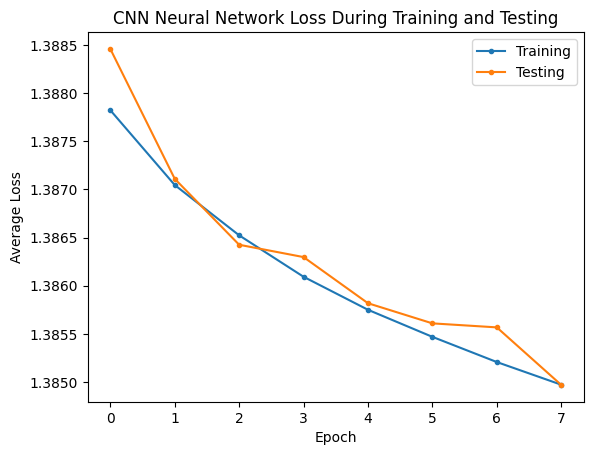

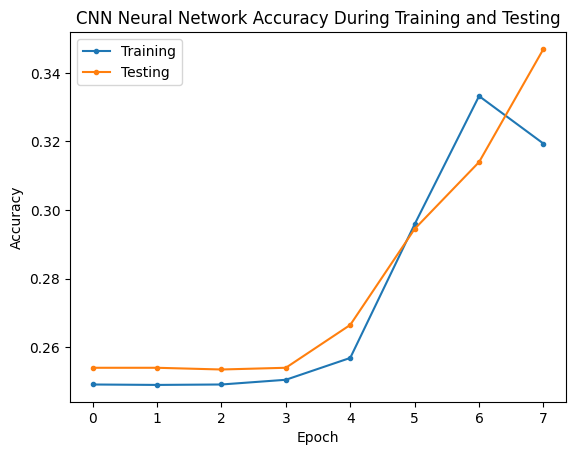

In [16]:
plt.plot(df['epoch'], df['training_avg_loss'], label='Training', marker='.')
plt.plot(df['epoch'], df['test_avg_loss'], label='Testing', marker='.')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('CNN Neural Network Loss During Training and Testing')
plt.legend()
plt.show()

plt.plot(df['epoch'], df['training_accuracy'], label='Training', marker='.')
plt.plot(df['epoch'], df['test_accuracy'], label='Testing', marker='.')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Neural Network Accuracy During Training and Testing')
plt.legend()
plt.show()

## 3.2.3 Model Analysis
- Print how many parameters each neural network has.
- Does more parameters always mean better performance?

In [72]:
def NN_param_summary(
        model: nn.Module,
        show_empty_modules: bool = False
    ) -> None:
    '''
    Print a list/summary of neural network layers with their names.
    Includes layers with no trainable parameters (e.g. nn.ReLU()).
    '''
    total_num: int = 0

    for name, module in model.named_modules():
        if name == '': continue    # first entry is always the model itself, with empty string as name, (no parameters)
        params = list(module.parameters(recurse=False))

        if (len(params) == 0) and (not show_empty_modules): continue    # detect empties, go to next loop if we dont want to see them
        
        print(f'{name}:')

        if len(params) == 0:
            print('\t(no parameters)')
        else:
            for param_name, param in module.named_parameters(recurse=False):
                print(f'\t{param_name}:')

                n = param.numel()
                print(f'\t\tShape: {tuple(param.shape)}')
                print(f'\t\tNumber: {n:,}')
                total_num += n
    print(f'-------------------------\nTotal parameters: {total_num:,}')

print('MLP Model:')
NN_param_summary(MLP_model)

MLP Model:
linear_relu_stack.0:
	weight:
		Shape: (512, 12288)
		Number: 6,291,456
	bias:
		Shape: (512,)
		Number: 512
linear_relu_stack.2:
	weight:
		Shape: (512, 512)
		Number: 262,144
	bias:
		Shape: (512,)
		Number: 512
linear_relu_stack.4:
	weight:
		Shape: (4, 512)
		Number: 2,048
	bias:
		Shape: (4,)
		Number: 4
-------------------------
Total parameters: 6,556,676


In [ ]:
print('CNN Model:')
NN_param_summary(CNN_model)

CNN Model:
conv_layers.0:
	weight:
		Shape: (32, 3, 3, 3)
		Number: 864
	bias:
		Shape: (32,)
		Number: 32
conv_layers.3:
	weight:
		Shape: (64, 32, 3, 3)
		Number: 18,432
	bias:
		Shape: (64,)
		Number: 64
classifier.1:
	weight:
		Shape: (128, 16384)
		Number: 2,097,152
	bias:
		Shape: (128,)
		Number: 128
classifier.3:
	weight:
		Shape: (4, 128)
		Number: 512
	bias:
		Shape: (4,)
		Number: 4
-------------------------
Total parameters: 2,117,188


### 3.2.4 Hyperparameter Tuning
- Use your best model and try to improve its performance by changing its architecture. Possible changes include:
    - Normalization Layers
    - Regularization (Optimizer or Layers)
    - Different Activation Functions
    - Different Learning Rates
    - Increase the number of layers or neurons
- Report which changes seem effective and which do not.

### 3.2.5 Evaluation on the test set
You have now tuned the model hypterparameters to achieve the best accuracy on the test set.
- Why can it become problematic to tune hyperparameters on the test set? What are possible solutions to keep this overfitting in check?